# Projekt Sieci Złożone: Analiza Społeczności na Różnych Poziomach Gęstości

Ten notatnik analizuje i porównuje wyniki dla całej sieci (SIMILAR) oraz trzech różnych progów filtrowania (LOW, MED, HIGH).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from neo4j import GraphDatabase
import warnings
warnings.filterwarnings('ignore')

# Ustawienia wykresów
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Konfiguracja połączenia
URI = os.environ.get("NEO4J_URI", "neo4j://neo4j:7687")
USER = "neo4j"
PASSWORD = "password"

driver = GraphDatabase.driver(URI, auth=(USER, PASSWORD))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return pd.DataFrame([r.values() for r in result], columns=result.keys())

## 0. Konfiguracja Eksperymentu
Ustaw poniżej parametry obecnego eksperymentu, aby tytuły wykresów odzwierciedlały analizowane dane.

In [ ]:
# TEN PARAMETR ZMIENIAJ W ZALEZNOSCI OD TEGO CO ZAOIMPOTOWALES DO BAZY NEO4J
PLAYTIME_MINUTES = 600  # np. 0, 240, 600
# Etykiety do ignorowania przy analizie gatunkowej (nie są prawdziwymi gatunkami)
NOISE_GENRES = ['Indie', 'Free to Play', 'Early Access']


EXPERIMENT_TITLE = f" (Min. Playtime: {PLAYTIME_MINUTES} min)"
print(f"Obecny kontekst eksperymentu: {EXPERIMENT_TITLE}")


Obecny kontekst eksperymentu:  (Min. Playtime: 600 min)


## 1. Porównanie Podstawowych Statystyk Wszystkich Typów Relacji
Sprawdzamy statystyki dla pełnego grafu oraz przefiltrowanych wersji.

In [3]:
rel_types = ['SIMILAR', 'SIMILAR_LOW', 'SIMILAR_MED', 'SIMILAR_HIGH']
stats = []

for rel in rel_types:
    query = f"""
    MATCH (n:Game)
    WITH count(n) AS total_nodes
    OPTIONAL MATCH ()-[r:{rel}]->()
    WITH total_nodes, count(r) AS num_edges
    MATCH (n:Game)
    WHERE apoc.node.degree(n, '{rel}') > 0
    WITH total_nodes, num_edges, count(n) AS active_nodes, max(apoc.node.degree(n, '{rel}')) AS max_deg, avg(apoc.node.degree(n, '{rel}')) AS avg_deg
    RETURN '{rel}' AS rel_type, 
           total_nodes, 
           active_nodes, 
           total_nodes - active_nodes AS isolated_nodes,
           num_edges, 
           max_deg, 
           avg_deg, 
           CASE WHEN active_nodes > 1 THEN (num_edges * 2.0) / (active_nodes * (active_nodes - 1)) ELSE 0 END AS density_active
    """
    stats.append(run_query(query))

df_stats = pd.concat(stats).reset_index(drop=True)
display(df_stats)


,rel_type,total_nodes,active_nodes,isolated_nodes,num_edges,max_deg,avg_deg,density_active
0,SIMILAR,44023,14288,29735,4550251,11520,636.933231,0.044581
1,SIMILAR_LOW,44023,4928,39095,706295,4256,286.645698,0.058179
2,SIMILAR_MED,44023,1929,42094,149892,1759,155.409020,0.080606
3,SIMILAR_HIGH,44023,766,43257,27769,713,72.503916,0.094776


## 1b. Rozkład Stopni (Degree Distribution)
Wykres log-log pozwala ocenić, czy sieć ma charakter scale-free (rozkład potęgowy).

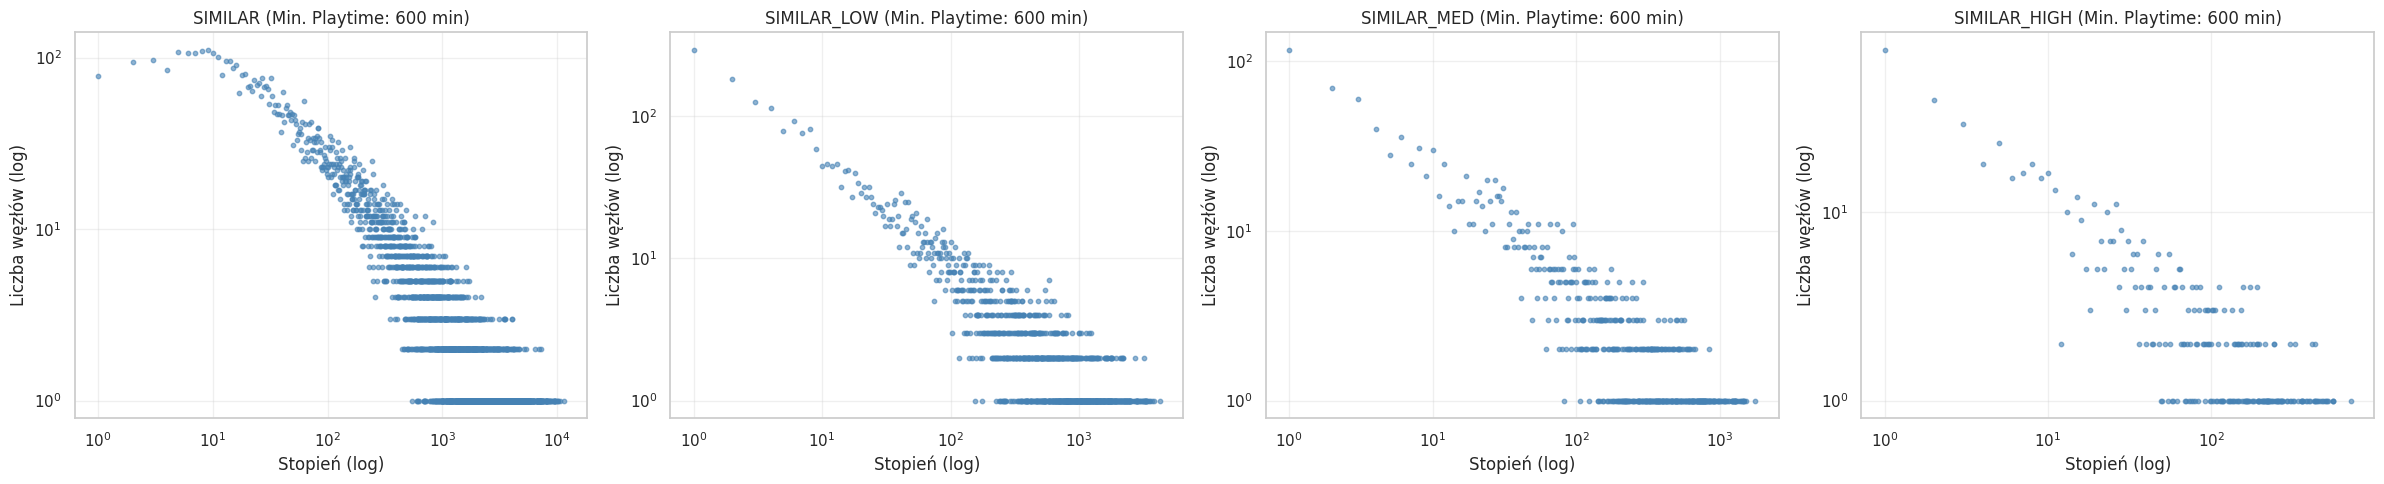

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, rel in enumerate(['SIMILAR', 'SIMILAR_LOW', 'SIMILAR_MED', 'SIMILAR_HIGH']):
    q_deg = f"""
    MATCH (g:Game)
    WHERE apoc.node.degree(g, '{rel}') > 0
    RETURN apoc.node.degree(g, '{rel}') AS degree
    """
    df_deg = run_query(q_deg)
    
    if not df_deg.empty:
        deg_counts = df_deg['degree'].value_counts().sort_index()
        axes[i].scatter(deg_counts.index, deg_counts.values, s=10, alpha=0.6, color='steelblue')
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_title(f'{rel}{EXPERIMENT_TITLE}')
        axes[i].set_xlabel('Stopień (log)')
        axes[i].set_ylabel('Liczba węzłów (log)')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 1c. Rozkład Gatunków w Sieci
Jakie gatunki dominują w całej bazie gier? Ile gatunków ma typowa gra? Te wykresy dają kontekst bazowy dla dalszej analizy społeczności.

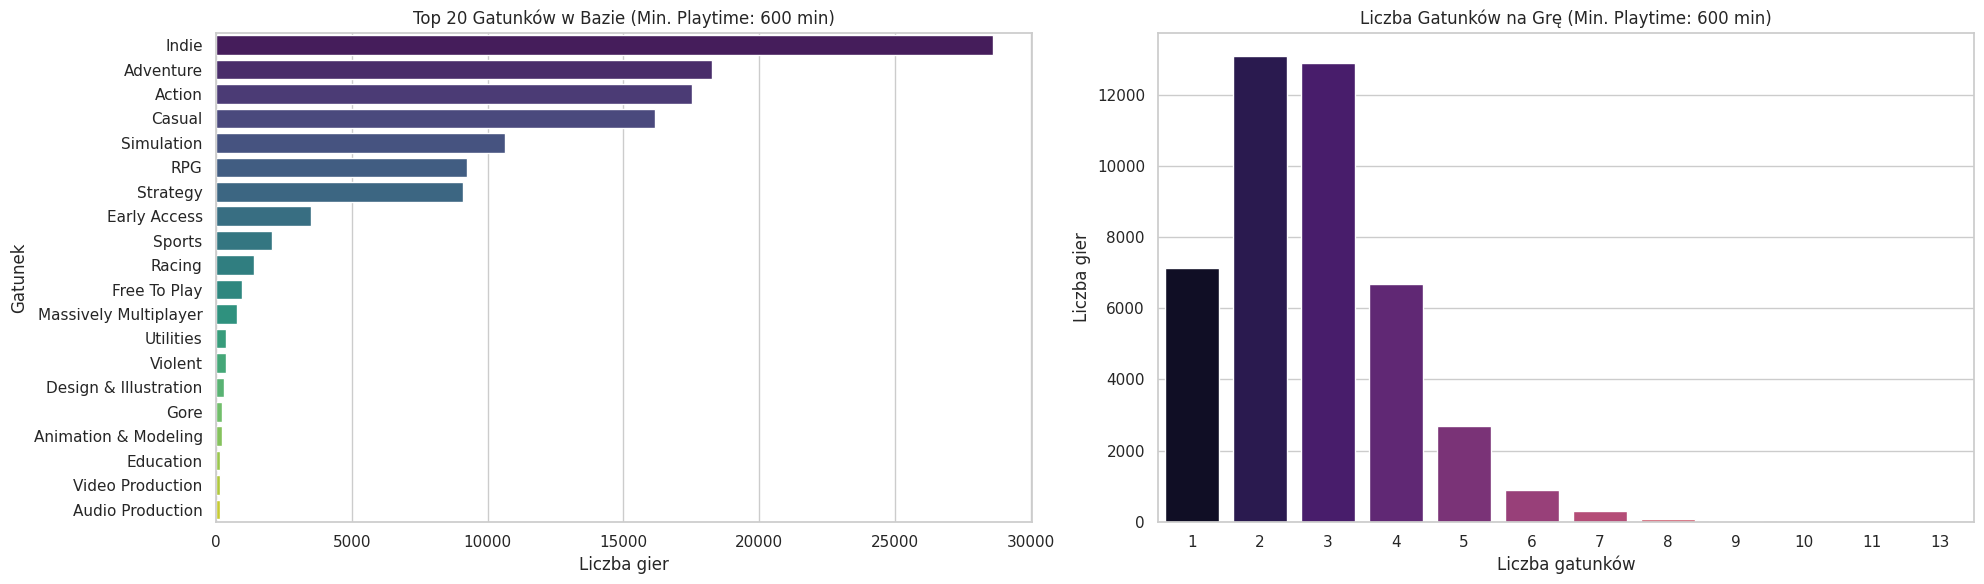

Średnia liczba gatunków na grę: 2.76


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# 1. Top 20 najczęstszych gatunków
q_genre_dist = """
MATCH (g:Game)
WHERE g.genres IS NOT NULL AND g.genres <> ''
UNWIND split(g.genres, '|') AS genre
RETURN genre, count(*) AS count
ORDER BY count DESC
LIMIT 20
"""
df_gd = run_query(q_genre_dist)
sns.barplot(data=df_gd, y='genre', x='count', palette='viridis', ax=axes[0])
axes[0].set_title(f'Top 20 Gatunków w Bazie{EXPERIMENT_TITLE}')
axes[0].set_xlabel('Liczba gier')
axes[0].set_ylabel('Gatunek')

# 2. Ile gatunków ma typowa gra?
q_genre_per_game = """
MATCH (g:Game)
WHERE g.genres IS NOT NULL AND g.genres <> ''
RETURN size(split(g.genres, '|')) AS num_genres, count(*) AS count
ORDER BY num_genres
"""
df_gpg = run_query(q_genre_per_game)
sns.barplot(data=df_gpg, x='num_genres', y='count', palette='magma', ax=axes[1])
axes[1].set_title(f'Liczba Gatunków na Grę{EXPERIMENT_TITLE}')
axes[1].set_xlabel('Liczba gatunków')
axes[1].set_ylabel('Liczba gier')

plt.tight_layout()
plt.show()

print(f"Średnia liczba gatunków na grę: {(df_gpg['num_genres'] * df_gpg['count']).sum() / df_gpg['count'].sum():.2f}")


## 2. Projekcja GDS i Algorytm Louvain dla poszczególnych progów
Odpalamy algorytm detekcji społeczności dla 3 przefiltrowanych sieci, zapisując wyniki do oddzielnych właściwości (community_id_low, med, high).

In [6]:
# Oczyszczanie ewentualnych starych projekcji
for suffix in ['ALL', 'LOW', 'MED', 'HIGH']:
    try:
        with driver.session() as session:
            session.run(f"CALL gds.graph.drop('games_{suffix.lower()}', false)")
    except: pass

louvain_results = []

for suffix in ['ALL', 'LOW', 'MED', 'HIGH']:
    rel_type = "SIMILAR" if suffix == 'ALL' else f"SIMILAR_{suffix}"
    prop_name = f"community_id_{suffix.lower()}"
    graph_name = f"games_{suffix.lower()}"
    
    print(f"Przetwarzanie {rel_type}...")
    
    # 1. Tworzenie projekcji natywnej (Nieskierowanej dla algorytmu Leiden)
    query_project = f"""
    CALL gds.graph.project(
      '{graph_name}',
      'Game',
      {{ {rel_type}: {{ orientation: 'UNDIRECTED', properties: 'jaccard' }} }}
    ) YIELD nodeCount, relationshipCount
    """
    run_query(query_project)
    
    # 2. Uruchamianie algorytmu Leiden (nowoczesnego następcy Louvain) z parametrem rozdzielczości
    query_louvain = f"""
    CALL gds.leiden.write('{graph_name}', {{
      relationshipWeightProperty: 'jaccard',
      writeProperty: '{prop_name}',
      gamma: 2.0
    }})
    YIELD communityCount, modularity
    RETURN '{rel_type}' AS rel_type, communityCount, modularity
    """
    louvain_results.append(run_query(query_louvain))

df_louvain = pd.concat(louvain_results).reset_index(drop=True)
display(df_louvain)
print("Społeczności zostały zapisane w Neo4j!")


Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)", position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'column': 1, 'offset': 0, 'line': 1}}> for query: "CALL gds.graph.drop('games_all', false)"
Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="The query used a deprecated field from a procedure. ('schema' returned by 'gds.graph.drop' is deprecated.)", position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classi

Przetwarzanie SIMILAR...
Przetwarzanie SIMILAR_LOW...
Przetwarzanie SIMILAR_MED...
Przetwarzanie SIMILAR_HIGH...


,rel_type,communityCount,modularity
0,SIMILAR,29795,0.250735
1,SIMILAR_LOW,39176,0.082720
2,SIMILAR_MED,42162,0.065414
3,SIMILAR_HIGH,43305,0.059296


Społeczności zostały zapisane w Neo4j!


## 3. Rozkład Wielkości Społeczności (Dla wszystkich progów)

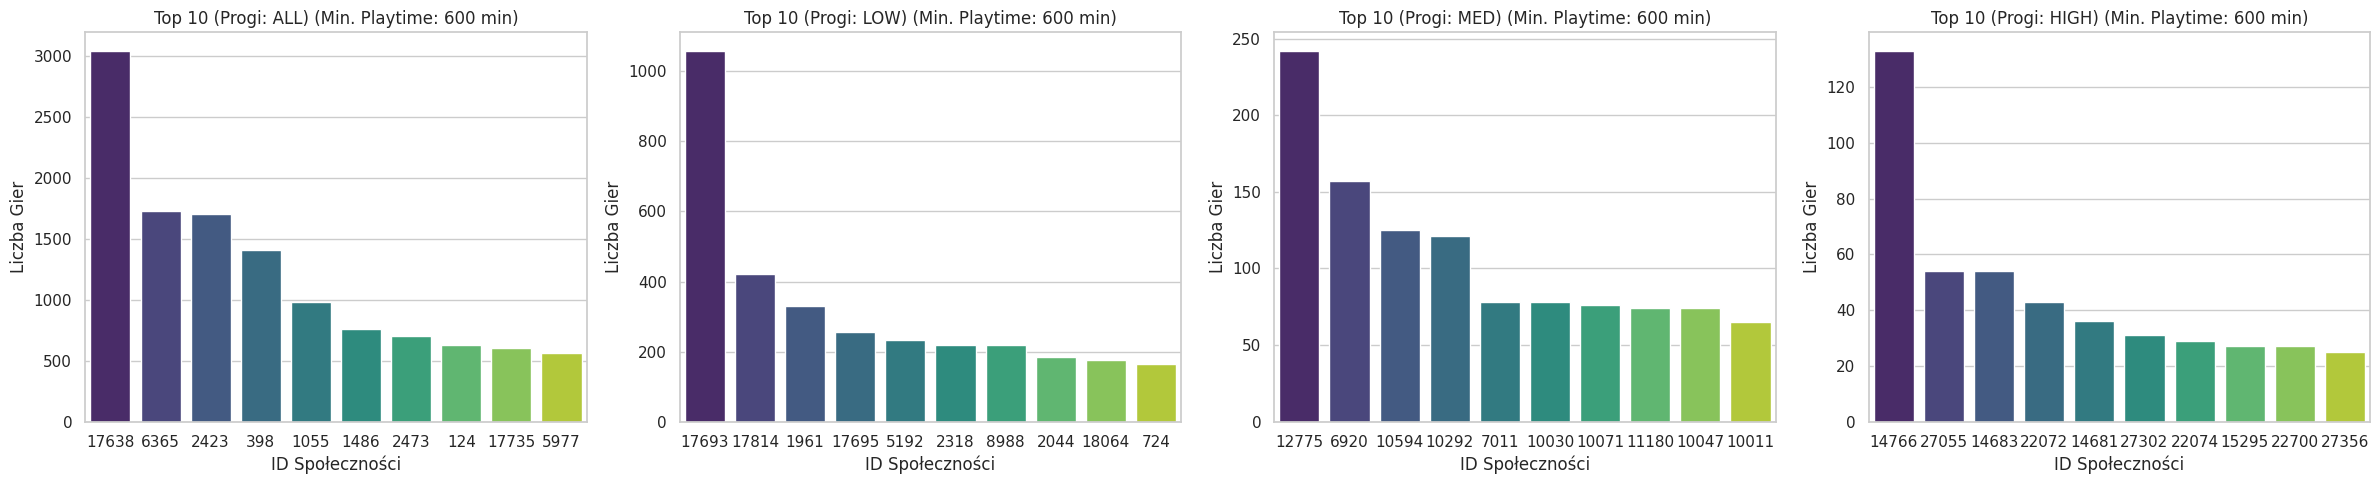

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, suffix in enumerate(['all', 'low', 'med', 'high']):
    prop = f"community_id_{suffix}"
    rel = "SIMILAR" if suffix == 'all' else f"SIMILAR_{suffix.upper()}"
    
    query = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, '{rel}') > 0
    RETURN g.{prop} AS community, count(g) AS size
    ORDER BY size DESC
    LIMIT 10
    """
    df = run_query(query)
    sns.barplot(data=df, x='community', y='size', order=df['community'], palette='viridis', ax=axes[i])
    axes[i].set_title(f'Top 10 (Progi: {suffix.upper()}){EXPERIMENT_TITLE}')
    axes[i].set_xlabel('ID Społeczności')
    axes[i].set_ylabel('Liczba Gier')

plt.tight_layout()
plt.show()


## 3b. Porównanie różnych metryk podobieństwa
Sprawdzamy, jak zmiana metryki (Jaccard, Cosine, Overlap, Resource Allocation) na tych samych krawędziach (SIMILAR_MED) wpływa na algorytm Leiden.

In [8]:
metrics = ['jaccard', 'cosine', 'overlap', 'resource_allocation']

try: driver.session().run("CALL gds.graph.drop('games_metrics', false)")
except: pass

print("Tworzenie projekcji z wieloma metrykami...")
query_metrics_proj = """
CALL gds.graph.project(
  'games_metrics',
  'Game',
  { SIMILAR_MED: { orientation: 'UNDIRECTED', properties: ['jaccard', 'cosine', 'overlap', 'resource_allocation'] } }
) YIELD nodeCount
"""
run_query(query_metrics_proj)

metrics_results = []
for metric in metrics:
    print(f"Uruchamianie Leiden dla metryki: {metric}")
    q = f"""
    CALL gds.leiden.write('games_metrics', {{
      relationshipWeightProperty: '{metric}',
      writeProperty: 'community_{metric}',
      gamma: 2.0
    }})
    YIELD communityCount, modularity
    RETURN '{metric}' AS metric, communityCount, modularity
    """
    metrics_results.append(run_query(q))

df_metrics = pd.concat(metrics_results).reset_index(drop=True)
display(df_metrics)


Tworzenie projekcji z wieloma metrykami...
Uruchamianie Leiden dla metryki: jaccard
Uruchamianie Leiden dla metryki: cosine
Uruchamianie Leiden dla metryki: overlap
Uruchamianie Leiden dla metryki: resource_allocation


,metric,communityCount,modularity
0,jaccard,42157,0.065361
1,cosine,42157,0.057622
2,overlap,42141,0.054567
3,resource_allocation,42159,0.021712


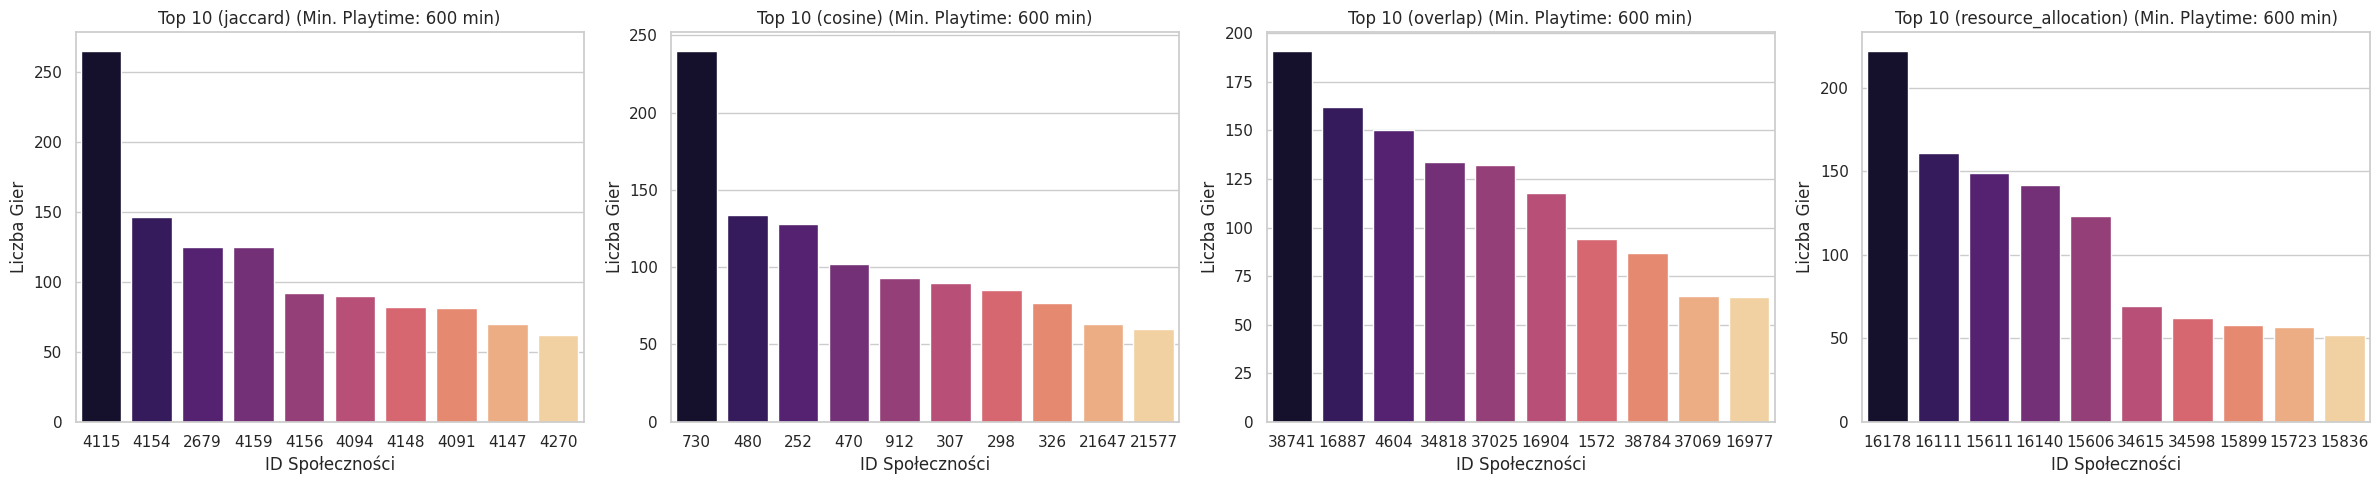

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, metric in enumerate(metrics):
    prop = f"community_{metric}"
    query = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, 'SIMILAR_MED') > 0
    RETURN g.{prop} AS community, count(g) AS size
    ORDER BY size DESC
    LIMIT 10
    """
    df = run_query(query)
    sns.barplot(data=df, x='community', y='size', order=df['community'], palette='magma', ax=axes[i])
    axes[i].set_title(f'Top 10 ({metric}){EXPERIMENT_TITLE}')
    axes[i].set_xlabel('ID Społeczności')
    axes[i].set_ylabel('Liczba Gier')

plt.tight_layout()
plt.show()


## 3c. Wpływ parametru Gamma (Rozdzielczość społeczności)
Algorytm Leiden pozwala na kontrolowanie wielkości klastrów za pomocą parametru `gamma`. Sprawdzamy, jak wpływa on na podział dla krawędzi SIMILAR_MED (metryka: jaccard).

In [10]:
gammas = [0.5, 1.0, 1.5, 2.0, 3.0]
gamma_results = []

for g_val in gammas:
    prop_g = str(g_val).replace('.', '_')
    print(f"Uruchamianie Leiden dla gamma: {g_val}")
    q = f"""
    CALL gds.leiden.write('games_metrics', {{
      relationshipWeightProperty: 'jaccard',
      writeProperty: 'community_gamma_{prop_g}',
      gamma: {g_val}
    }})
    YIELD communityCount, modularity
    RETURN {g_val} AS gamma, communityCount, modularity
    """
    gamma_results.append(run_query(q))

df_gamma = pd.concat(gamma_results).reset_index(drop=True)
display(df_gamma)


Uruchamianie Leiden dla gamma: 0.5
Uruchamianie Leiden dla gamma: 1.0
Uruchamianie Leiden dla gamma: 1.5
Uruchamianie Leiden dla gamma: 2.0
Uruchamianie Leiden dla gamma: 3.0


,gamma,communityCount,modularity
0,0.5,42111,0.501805
1,1.0,42108,0.178501
2,1.5,42121,0.098766
3,2.0,42159,0.065674
4,3.0,42234,0.041088


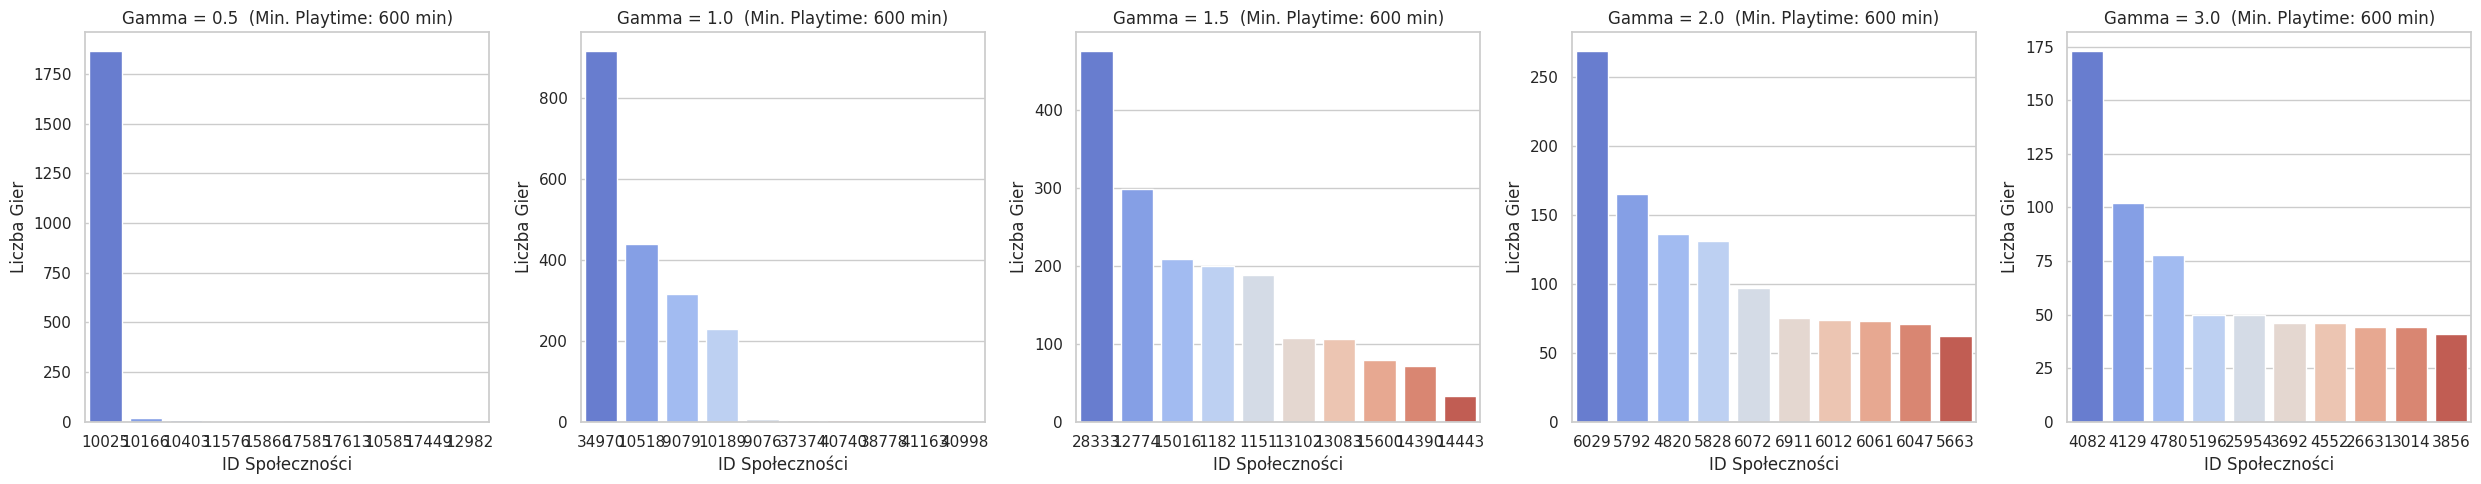

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, g_val in enumerate(gammas):
    prop_g = str(g_val).replace('.', '_')
    prop = f"community_gamma_{prop_g}"
    query = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, 'SIMILAR_MED') > 0
    RETURN g.{prop} AS community, count(g) AS size
    ORDER BY size DESC
    LIMIT 10
    """
    df = run_query(query)
    sns.barplot(data=df, x='community', y='size', order=df['community'], palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'Gamma = {g_val} {EXPERIMENT_TITLE}')
    axes[i].set_xlabel('ID Społeczności')
    axes[i].set_ylabel('Liczba Gier')

plt.tight_layout()
plt.show()


## 4. Dominujące Gatunki w Społecznościach (Dla progów ALL, LOW, MED, HIGH)

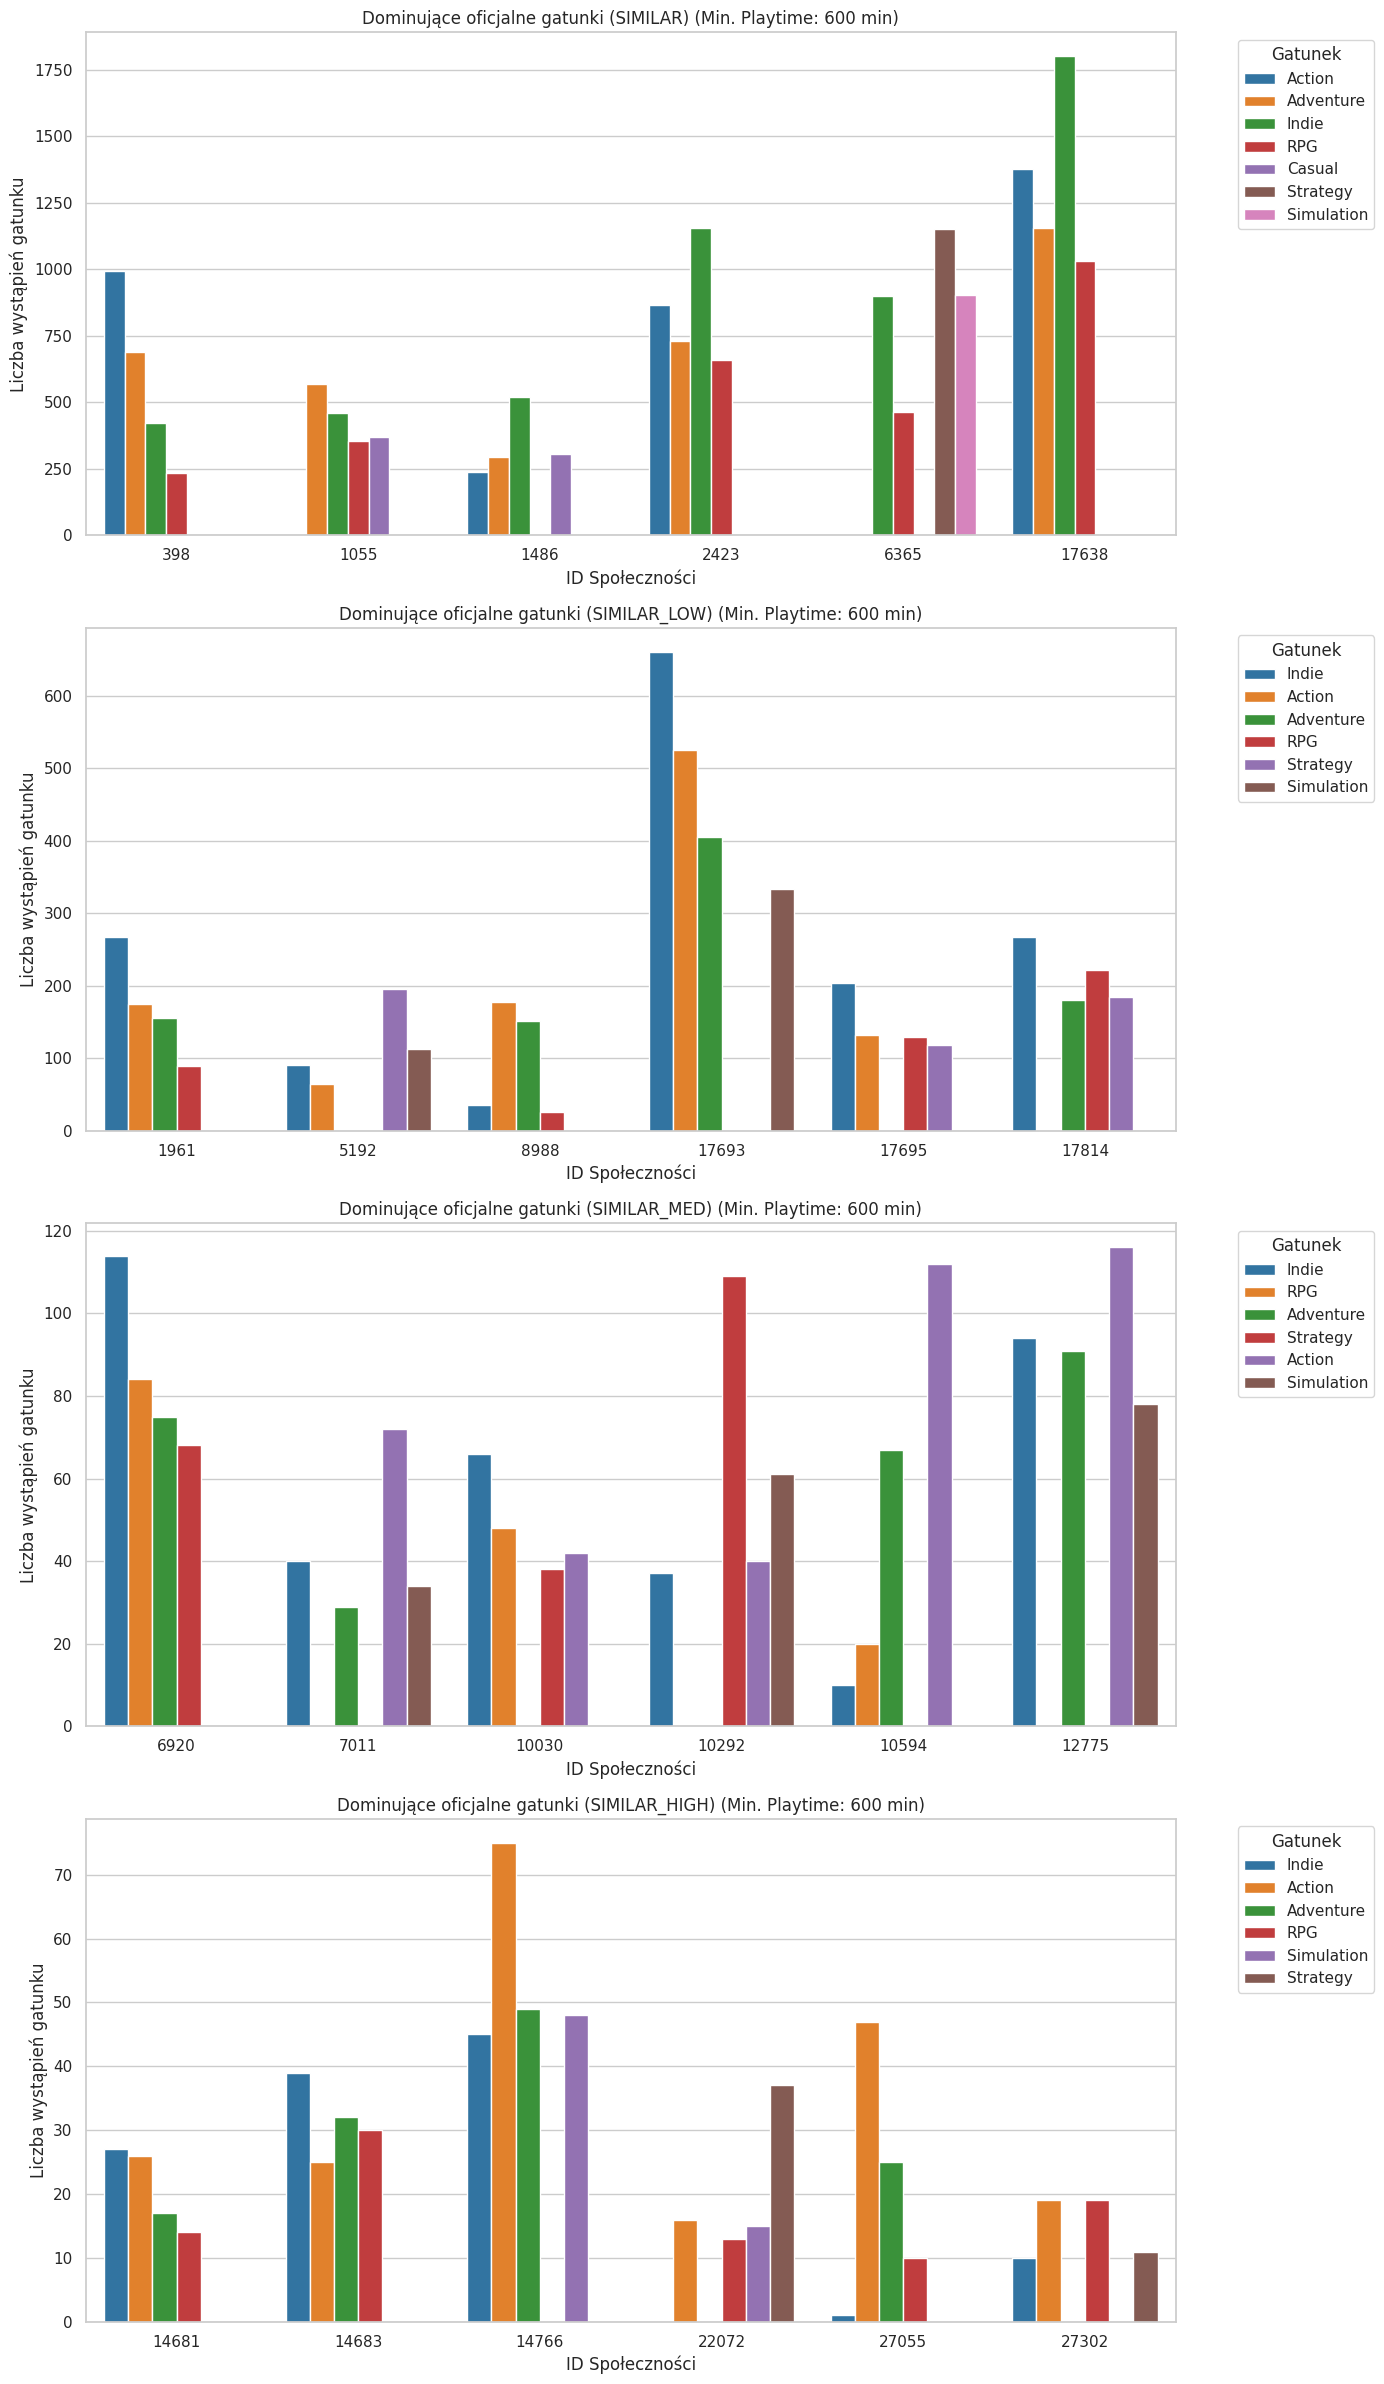

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 24))
plt.subplots_adjust(hspace=0.4)

for i, suffix in enumerate(['all', 'low', 'med', 'high']):
    prop = f"community_id_{suffix}"
    rel = "SIMILAR" if suffix == 'all' else f"SIMILAR_{suffix.upper()}"
    
    query_genres = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, '{rel}') > 0
    WITH g.{prop} AS community, count(g) AS size
    ORDER BY size DESC LIMIT 6

    MATCH (g:Game)
    WHERE g.{prop} = community AND g.genres IS NOT NULL AND g.genres <> ''
    UNWIND split(g.genres, '|') AS genre
    WITH community, genre, count(*) AS count
    ORDER BY count DESC
    WITH community, collect({{genre: genre, count: count}})[0..4] AS top_genres
    UNWIND top_genres AS tg
    RETURN community, tg.genre AS genre, tg.count AS count
    """
    df_genres = run_query(query_genres)
    
    if not df_genres.empty:
        sns.barplot(data=df_genres, x='community', y='count', hue='genre', palette='tab10', ax=axes[i])
        axes[i].set_title(f'Dominujące oficjalne gatunki ({rel}){EXPERIMENT_TITLE}')
        axes[i].set_xlabel('ID Społeczności')
        axes[i].set_ylabel('Liczba wystąpień gatunku')
        axes[i].legend(title='Gatunek', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


## 5. Homofilia Gatunkowa (Z wykorzystaniem krawędzi HIGH)
Używając najsilniejszych powiązań (SIMILAR_HIGH) badamy, które gatunki łączą się w hermetyczne grupy.

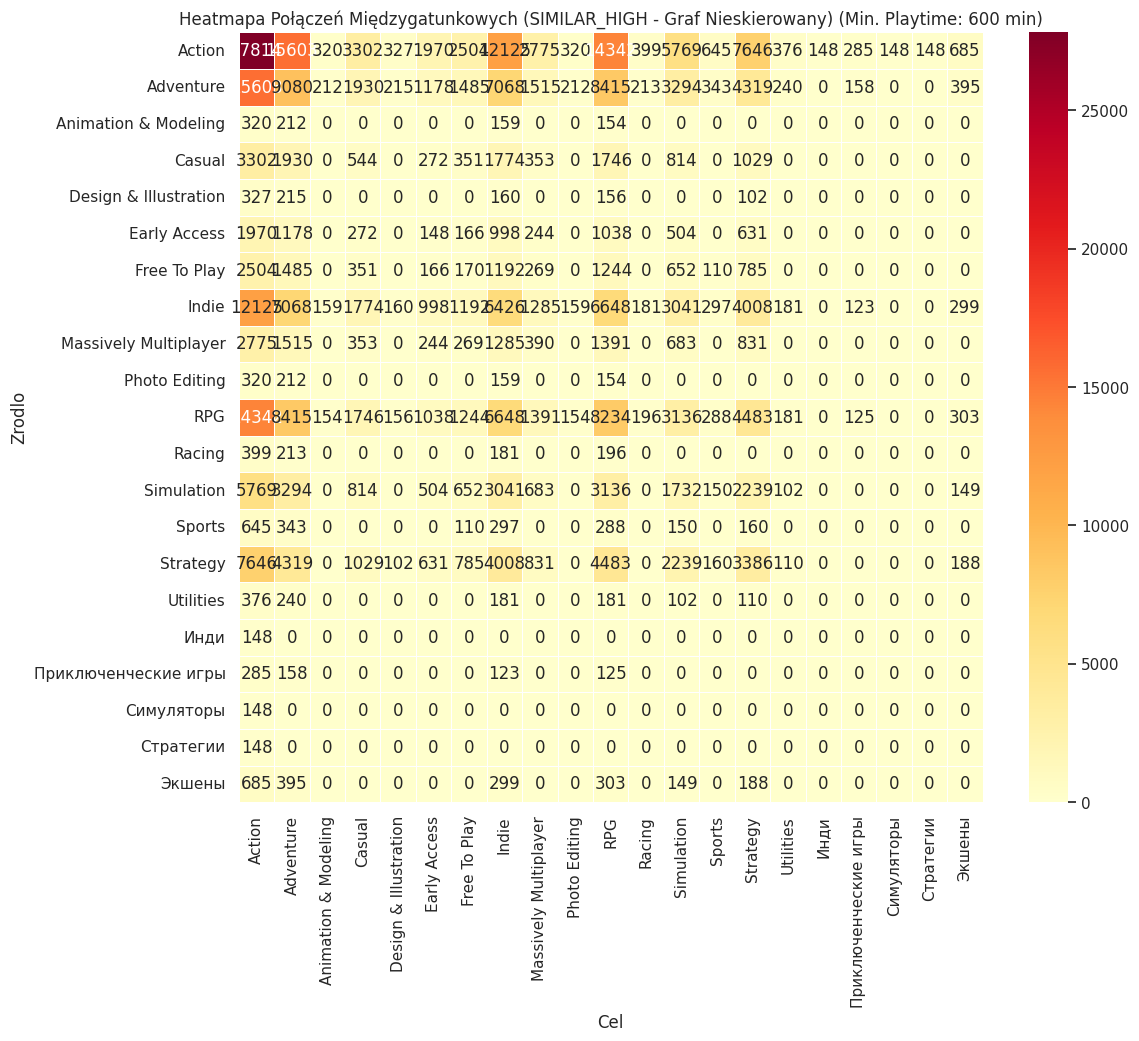

In [13]:
query_homophily = """
MATCH (n:Game)-[r:SIMILAR_HIGH]-(m:Game)
WHERE n.genres IS NOT NULL AND m.genres IS NOT NULL
UNWIND split(n.genres, '|') AS genre_n
UNWIND split(m.genres, '|') AS genre_m
WITH genre_n, genre_m, count(r) AS connections
WHERE connections > 100
RETURN genre_n AS Zrodlo, genre_m AS Cel, connections AS Sila_Polaczenia
ORDER BY Sila_Polaczenia DESC
LIMIT 400
"""
df_homophily = run_query(query_homophily)
pivot = df_homophily.pivot(index='Zrodlo', columns='Cel', values='Sila_Polaczenia').fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5)
plt.title(f'Heatmapa Połączeń Międzygatunkowych (SIMILAR_HIGH - Graf Nieskierowany){EXPERIMENT_TITLE}')
plt.show()


## 5. Kompleksowa Analiza Kombinacji Parametrów (Grid Search)\nBadamy różne kombinacje progów, metryk i wartości gamma. Aby uniknąć przepełnienia pamięci i zbyt długiego czasu wykonania, wybrano najbardziej reprezentatywne warianty. Możesz edytować listy poniżej, by zbadać inne ułożenia!

In [14]:
import itertools

# Zdefiniuj warianty do przetestowania
grid_thresholds = ['ALL','LOW','MED', 'HIGH']
grid_metrics = ['jaccard', 'cosine', 'overlap', 'resource_allocation']
grid_gammas = [1.0, 1.5, 2.0, 2.5, 3.0]

combinations = list(itertools.product(grid_thresholds, grid_metrics, grid_gammas))
print(f"Liczba kombinacji do przetestowania: {len(combinations)}")

grid_results = []

for thresh in grid_thresholds:
    rel_name = "SIMILAR" if thresh == 'ALL' else f"SIMILAR_{thresh}"
    graph_name = f"grid_{thresh.lower()}"
    
    # Liczenie aktywnych węzłów dla danego progu
    q_active = f"MATCH (g:Game) WHERE apoc.node.degree(g, '{rel_name}') > 0 RETURN count(g) AS activeNodes"
    active_nodes = run_query(q_active)['activeNodes'][0]
    
    # Czyszczenie i nowa projekcja dla danego progu z wieloma metrykami
    try: driver.session().run(f"CALL gds.graph.drop('{graph_name}', false)")
    except: pass
    
    q_proj = f"""
    CALL gds.graph.project(
      '{graph_name}',
      'Game',
      {{ {rel_name}: {{ orientation: 'UNDIRECTED', properties: {grid_metrics} }} }}
    ) YIELD nodeCount
    """
    print(f"Tworzenie projekcji: {graph_name}...")
    proj_res = run_query(q_proj)
    total_nodes = proj_res['nodeCount'][0] if not proj_res.empty else 0
    
    for metric in grid_metrics:
        for gamma in grid_gammas:
            prop_name = f"comm_{thresh.lower()}_{metric}_{str(gamma).replace('.', '_')}"
            
            q = f"""
            CALL gds.leiden.write('{graph_name}', {{
              relationshipWeightProperty: '{metric}',
              writeProperty: '{prop_name}',
              gamma: {gamma}
            }})
            YIELD communityCount, modularity
            RETURN '{thresh}' AS Threshold, '{metric}' AS Metric, {gamma} AS Gamma, 
                   communityCount, modularity, '{prop_name}' AS prop_name,
                   {active_nodes} AS activeNodes, {total_nodes} AS totalNodes
            """
            res = run_query(q)
            grid_results.append(res)

df_grid = pd.concat(grid_results).reset_index(drop=True)
display(df_grid.sort_values(by='modularity', ascending=False))


Liczba kombinacji do przetestowania: 80
Tworzenie projekcji: grid_all...
Tworzenie projekcji: grid_low...
Tworzenie projekcji: grid_med...
Tworzenie projekcji: grid_high...


,Threshold,Metric,Gamma,communityCount,modularity,prop_name,activeNodes,totalNodes
0,ALL,jaccard,1.0,29818,0.426197,comm_all_jaccard_1_0,14288,44023
5,ALL,cosine,1.0,29768,0.356193,comm_all_cosine_1_0,14288,44023
1,ALL,jaccard,1.5,29817,0.308846,comm_all_jaccard_1_5,14288,44023
10,ALL,overlap,1.0,29742,0.267829,comm_all_overlap_1_0,14288,44023
2,ALL,jaccard,2.0,29791,0.252350,comm_all_jaccard_2_0,14288,44023
...,...,...,...,...,...,...,...,...
58,MED,resource_allocation,2.5,42200,0.009291,comm_med_resource_allocation_2_5,1929,44023
39,LOW,resource_allocation,3.0,39288,0.005383,comm_low_resource_allocation_3_0,4928,44023
78,HIGH,resource_allocation,2.5,43330,0.004631,comm_high_resource_allocation_2_5,766,44023
59,MED,resource_allocation,3.0,42240,0.001896,comm_med_resource_allocation_3_0,1929,44023


In [32]:
# Rysowanie wykresów dla każdej kombinacji (Rozmiar klastrów + Gatunki)
num_combos = len(df_grid)
fig, axes = plt.subplots(num_combos, 2, figsize=(20, 6 * num_combos))
plt.subplots_adjust(hspace=0.5)

for i, row in df_grid.iterrows():
    thresh = row['Threshold']
    metric = row['Metric']
    gamma = row['Gamma']
    prop = row['prop_name']
    modularity = row['modularity']
    comm_count = row['communityCount']
    active_n = row['activeNodes']
    total_n = row['totalNodes']
    
    rel_name = "SIMILAR" if thresh == 'ALL' else f"SIMILAR_{thresh}"
    
    print(f"Kombinacja: Próg={thresh:4s} | Metryka={metric:20s} | Gamma={gamma} ---> Modularity: {modularity:.4f} | Klastry: {comm_count} | Aktywne Węzły: {active_n} / {total_n}")
    
    title_suffix = f"[{thresh} | {metric} | g={gamma} | Mod: {modularity:.3f}]"
    
    # 1. Rozmiar klastrów
    q_size = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, '{rel_name}') > 0
    RETURN g.{prop} AS community, count(g) AS size
    ORDER BY size DESC LIMIT 10
    """
    df_size = run_query(q_size)
    if not df_size.empty:
        sns.barplot(data=df_size, x='community', y='size', order=df_size['community'], palette='viridis', ax=axes[i, 0])
    axes[i, 0].set_title(f'Wielkość Klastrów {title_suffix}')
    axes[i, 0].set_xlabel('ID')
    axes[i, 0].set_ylabel('Liczba gier')
    
    # 2. Gatunki
    q_genres = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, '{rel_name}') > 0
    WITH g.{prop} AS community, count(g) AS size
    ORDER BY size DESC LIMIT 5

    MATCH (g:Game)
    WHERE g.{prop} = community AND g.genres IS NOT NULL AND g.genres <> ''
    UNWIND split(g.genres, '|') AS genre
    WITH community, genre WHERE NOT genre IN ['Indie', 'Free to Play', 'Early Access']
    WITH community, genre, count(*) AS count
    ORDER BY count DESC
    WITH community, collect({{genre: genre, count: count}})[0..3] AS top_genres
    UNWIND top_genres AS tg
    RETURN community, tg.genre AS genre, tg.count AS count
    """

    df_genres = run_query(q_genres)
    if not df_genres.empty:
        sns.barplot(data=df_genres, x='community', y='count', hue='genre', palette='tab10', ax=axes[i, 1])
        axes[i, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[i, 1].set_title(f'Dominujące Gatunki {title_suffix}')
    axes[i, 1].set_xlabel('ID')
    axes[i, 1].set_ylabel('Wystąpienia')

plt.tight_layout()
plt.show()


Kombinacja: Próg=ALL  | Metryka=jaccard              | Gamma=1.0 ---> Modularity: 0.4262 | Klastry: 29818 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=jaccard              | Gamma=1.5 ---> Modularity: 0.3088 | Klastry: 29817 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=jaccard              | Gamma=2.0 ---> Modularity: 0.2524 | Klastry: 29791 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=jaccard              | Gamma=2.5 ---> Modularity: 0.2105 | Klastry: 29808 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=jaccard              | Gamma=3.0 ---> Modularity: 0.1863 | Klastry: 29818 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=cosine               | Gamma=1.0 ---> Modularity: 0.3562 | Klastry: 29768 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=cosine               | Gamma=1.5 ---> Modularity: 0.2422 | Klastry: 29769 | Aktywne Węzły: 14288 / 44023
Kombinacja: Próg=ALL  | Metryka=cosine   

## 6. Genre Purity Score (Czystość Gatunkowa Klastrów)
Dla każdej społeczności obliczamy jaki procent gier posiada dominujący gatunek. Wysoka czystość = klaster jest gatunkowo spójny.

Top-3 Genre Coverage (jaki % gier pokrywa top 3 gatunki w klastrze):


,Threshold,Metric,Gamma,Modularity,Avg_Top3_Coverage
64,HIGH,jaccard,3.0,0.032345,1.6956
41,MED,jaccard,1.5,0.100165,1.6785
61,HIGH,jaccard,1.5,0.084267,1.6667
43,MED,jaccard,2.5,0.049853,1.6639
40,MED,jaccard,1.0,0.187566,1.6558
...,...,...,...,...,...
35,LOW,resource_allocation,1.0,0.131784,1.3186
3,ALL,jaccard,2.5,0.210456,1.3084
11,ALL,overlap,1.5,0.170150,1.3015
2,ALL,jaccard,2.0,0.252350,1.2873


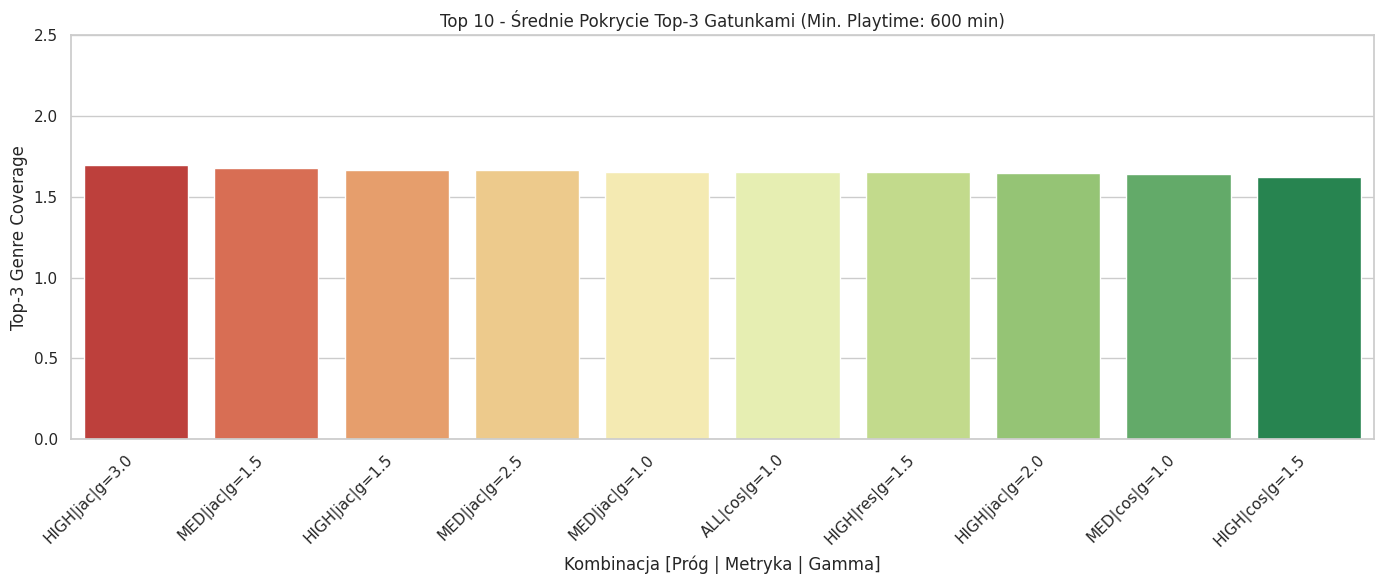

In [34]:
purity_results = []

for i, row in df_grid.iterrows():
    thresh = row['Threshold']
    metric = row['Metric']
    gamma = row['Gamma']
    prop = row['prop_name']
    modularity = row['modularity']
    rel_name = "SIMILAR" if thresh == 'ALL' else f"SIMILAR_{thresh}"
    
    # Pobierz top 10 klastrów
    q_top = f"""
    MATCH (g:Game)
    WHERE g.{prop} IS NOT NULL AND apoc.node.degree(g, '{rel_name}') > 0
    WITH g.{prop} AS community, count(g) AS community_size
    WHERE community_size >= 5
    RETURN community, community_size
    ORDER BY community_size DESC
    LIMIT 10
    """
    df_top = run_query(q_top)
    
    coverages = []
    for _, row_t in df_top.iterrows():
        comm_id = row_t['community']
        comm_size = row_t['community_size']
        
        q_g = f"""
        MATCH (g:Game)
        WHERE g.{prop} = {comm_id} AND g.genres IS NOT NULL AND g.genres <> ''
        UNWIND split(g.genres, '|') AS genre
        WITH genre WHERE NOT genre IN ['Indie', 'Free to Play', 'Early Access']
        RETURN genre, count(*) AS cnt
        ORDER BY cnt DESC
        LIMIT 3
        """

        df_g = run_query(q_g)
        if not df_g.empty:
            top3_count = df_g['cnt'].sum()
            coverage = top3_count / comm_size
            coverages.append(coverage)
    
    if coverages:
        avg_cov = round(sum(coverages) / len(coverages), 4)
        purity_results.append({
            'Threshold': thresh, 'Metric': metric, 'Gamma': gamma,
            'Modularity': modularity,
            'Avg_Top3_Coverage': avg_cov
        })

df_purity = pd.DataFrame(purity_results)
print("Top-3 Genre Coverage (jaki % gier pokrywa top 3 gatunki w klastrze):")
display(df_purity.sort_values(by='Avg_Top3_Coverage', ascending=False))

# Top 10 kombinacji wg Top-3 Coverage
fig, ax = plt.subplots(figsize=(14, 6))
df_purity_top = df_purity.sort_values(by='Avg_Top3_Coverage', ascending=False).head(10).copy()
df_purity_top['label'] = df_purity_top.apply(lambda r: f"{r['Threshold']}|{r['Metric'][:3]}|g={r['Gamma']}", axis=1)
sns.barplot(data=df_purity_top, x='label', y='Avg_Top3_Coverage', palette='RdYlGn', ax=ax)
ax.set_title(f'Top 10 - Średnie Pokrycie Top-3 Gatunkami{EXPERIMENT_TITLE}')
ax.set_xlabel('Kombinacja [Próg | Metryka | Gamma]')
ax.set_ylabel('Top-3 Genre Coverage')
ax.set_ylim(0, 2.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



## 6b. Szczegółowy Profil Gatunkowy Klastrów
Dla **najlepszej kombinacji** (wg Weighted Purity) wyświetlamy szczegółową tabelę każdego klastra: dominujący gatunek, purity, oraz top 5 gatunków.

Najlepsza kombinacja: Próg=HIGH | Metryka=jaccard | Gamma=3.0
Modularity: 0.0323 | Top-3 Coverage: 1.6956


,community,community_size,top3_coverage,top5_genres
0,3097,69,1.232,Action (39) | Simulation (24) | Adventure (22)...
1,39073,38,1.711,RPG (23) | Adventure (22) | Strategy (20) | Ac...
2,38950,30,1.567,Action (26) | Adventure (15) | RPG (6)
3,38985,27,1.667,Action (21) | Adventure (14) | RPG (10) | Stra...
4,26576,25,1.800,Strategy (23) | Action (11) | Simulation (11) ...
5,38878,21,2.190,Action (17) | RPG (17) | Adventure (12) | Stra...
6,3096,17,1.765,Action (17) | Adventure (11) | RPG (2)
7,38706,16,1.562,Action (13) | Adventure (9) | RPG (3) | Strate...
8,3869,16,2.062,Action (16) | Strategy (9) | Massively Multipl...
9,38970,15,1.400,Strategy (10) | RPG (8) | Simulation (3) | Act...


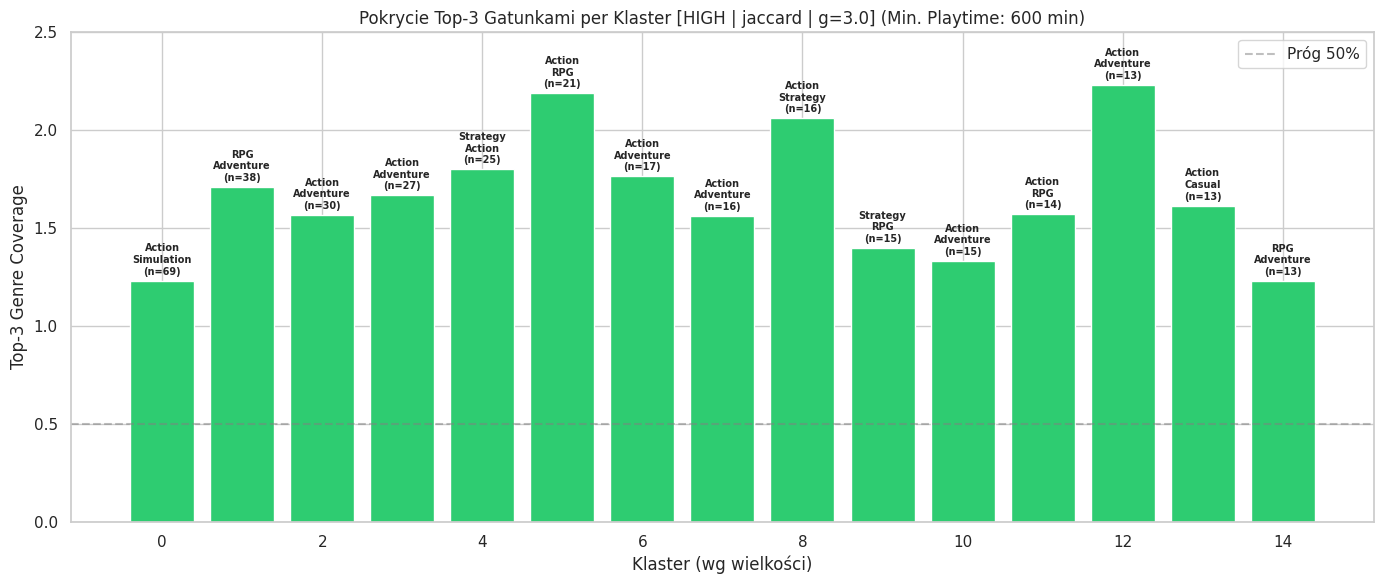

In [38]:
# Najlepsza kombinacja wg Top-3 Coverage
best = df_purity.sort_values(by='Avg_Top3_Coverage', ascending=False).iloc[0]
best_row = df_grid[(df_grid['Threshold'] == best['Threshold']) & 
                   (df_grid['Metric'] == best['Metric']) & 
                   (df_grid['Gamma'] == best['Gamma'])].iloc[0]

best_prop = best_row['prop_name']
best_thresh = best_row['Threshold']
best_rel = "SIMILAR" if best_thresh == 'ALL' else f"SIMILAR_{best_thresh}"

print(f"Najlepsza kombinacja: Próg={best_thresh} | Metryka={best['Metric']} | Gamma={best['Gamma']}")
print(f"Modularity: {best_row['modularity']:.4f} | Top-3 Coverage: {best['Avg_Top3_Coverage']:.4f}")
print("=" * 80)

q_top = f"""
MATCH (g:Game)
WHERE g.{best_prop} IS NOT NULL AND apoc.node.degree(g, '{best_rel}') > 0
WITH g.{best_prop} AS community, count(g) AS community_size
WHERE community_size >= 5
RETURN community, community_size
ORDER BY community_size DESC
LIMIT 15
"""
df_top = run_query(q_top)

detail_rows = []
for _, row_t in df_top.iterrows():
    comm_id = row_t['community']
    comm_size = row_t['community_size']
    
    q_g = f"""
        MATCH (g:Game)
        WHERE g.{best_prop} = {comm_id} AND g.genres IS NOT NULL AND g.genres <> ''
        UNWIND split(g.genres, '|') AS genre
        WITH genre WHERE NOT genre IN ['Indie', 'Free to Play', 'Early Access']
        RETURN genre, count(*) AS cnt
        ORDER BY cnt DESC
        LIMIT 5
        """

    df_g = run_query(q_g)
    if not df_g.empty:
        top3_count = df_g.head(3)['cnt'].sum()
        coverage = round(top3_count / comm_size, 3)
        top5_str = ' | '.join([f"{r['genre']} ({r['cnt']})" for _, r in df_g.iterrows()])
        detail_rows.append({
            'community': comm_id,
            'community_size': comm_size,
            'top3_coverage': coverage,
            'top5_genres': top5_str
        })

df_detail = pd.DataFrame(detail_rows)
display(df_detail)

# Wykres
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if c >= 0.7 else '#f39c12' if c >= 0.5 else '#e74c3c' for c in df_detail['top3_coverage']]
bars = ax.bar(range(len(df_detail)), df_detail['top3_coverage'], color=colors, edgecolor='white')

for j, (bar, row_d) in enumerate(zip(bars, df_detail.itertuples())):
    # Wyciągnij top 2 gatunki z opisu
    top2 = row_d.top5_genres.split(' | ')[:2]
    label = '\n'.join([g.split(' (')[0] for g in top2])
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f"{label}\n(n={row_d.community_size})", 
            ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Klaster (wg wielkości)')
ax.set_ylabel('Top-3 Genre Coverage')
ax.set_title(f'Pokrycie Top-3 Gatunkami per Klaster [{best_thresh} | {best["Metric"]} | g={best["Gamma"]}]{EXPERIMENT_TITLE}')
ax.set_ylim(0, 2.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Próg 50%')
ax.legend()
plt.tight_layout()
plt.show()


In [39]:
# Top 10 gier w każdym z 15 największych klastrów
for _, row_t in df_top.iterrows():
    comm_id = row_t['community']
    comm_size = row_t['community_size']
    
    q_games = f"""
    MATCH (g:Game)
    WHERE g.{best_prop} = {comm_id} AND g.name IS NOT NULL
    RETURN g.name AS game, g.genres AS genres
    LIMIT 10
    """
    df_games = run_query(q_games)
    
    print(f"\n{'='*80}")
    print(f"KLASTER {comm_id} (rozmiar: {comm_size} gier)")
    print(f"{'='*80}")
    for _, g in df_games.iterrows():
        print(f"  • {g['game']}  [{g['genres']}]")



KLASTER 3097 (rozmiar: 69 gier)
  • PUBG: BATTLEGROUNDS  [Action|Adventure|Massively Multiplayer|Free To Play]
  • Counter-Strike: Condition Zero  [Action]
  • Counter-Strike 2  [Action|Free To Play]
  • Totally Accurate Battlegrounds  [Action|Indie|Free To Play]
  • Dota 2  [Action|Strategy|Free To Play]
  • Rento Fortune: Online Dice Board Game (大富翁)  [Casual|Indie|Massively Multiplayer|Strategy]
  • Project Winter  [Action|Adventure|Casual|Indie|Strategy]
  • Chained Together  [Adventure|Casual|Indie|Simulation]
  • RV There Yet?  [Action|Adventure|Indie]
  • GRID 2  [Racing|Sports]

KLASTER 39073 (rozmiar: 38 gier)
  • Mirror  [Adventure|Indie|RPG]
  • Dota Underlords  [Casual|Strategy|Free To Play]
  • Black Myth: Wukong  [Action|Adventure|RPG]
  • Artifact  [Strategy]
  • DAVE THE DIVER  [Adventure|Casual|RPG|Simulation]
  • Backpack Battles  [Strategy]
  • Slay the Spire 2  [Indie|Strategy|Early Access]
  • Total War: THREE KINGDOMS  [Action|Strategy]
  • The Scroll Of Taiwu  [

## 7. Eksport Wyników do CSV
Zapisujemy kluczowe wyniki tego eksperymentu (z danym progiem playtime), aby później porównać je między różnymi importami.

In [40]:
import os

export_dir = 'results'
os.makedirs(export_dir, exist_ok=True)

# 1. Eksport statystyk sieci
df_stats['playtime_min'] = PLAYTIME_MINUTES
df_stats.to_csv(f'{export_dir}/stats_playtime_{PLAYTIME_MINUTES}.csv', index=False)

# 2. Eksport wyników Grid Search (modularity, community count)
df_grid['playtime_min'] = PLAYTIME_MINUTES
df_grid.to_csv(f'{export_dir}/grid_playtime_{PLAYTIME_MINUTES}.csv', index=False)

# 3. Eksport Genre Purity
df_purity['playtime_min'] = PLAYTIME_MINUTES
df_purity.to_csv(f'{export_dir}/purity_playtime_{PLAYTIME_MINUTES}.csv', index=False)

print(f"Wyniki zapisane do folderu '{export_dir}/' z tagiem playtime={PLAYTIME_MINUTES}")
print("Po uruchomieniu dla wszystkich progów (0, 240, 600), użyj sekcji 8 aby porównać.")


Wyniki zapisane do folderu 'results/' z tagiem playtime=600
Po uruchomieniu dla wszystkich progów (0, 240, 600), użyj sekcji 8 aby porównać.
